In [56]:
# --- 1. ADIM: VERİYİ OKUMA VE INDEX YAPMA ---
import pandas as pd

df = pd.read_csv("data/energy.csv")

df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

# Sadece PJM_Load sütununu al
df_prep = df[['PJM_Load']].copy()

# Sadece sağlam verinin olduğu dönemi filtrele (2002'de 1 satır var, 2003+ boş)
df_prep = df_prep.loc['1998':'2001']

# Kaç NaN var kontrol et
print("NaN sayısı:", df_prep['PJM_Load'].isna().sum())
print("Toplam satır:", len(df_prep))

# NaN olan satırları direkt sil
df_prep.dropna(inplace=True)

print("Temizleme sonrası satır:", len(df_prep))
print("İlk tarih:", df_prep.index.min())
print("Son tarih:", df_prep.index.max())

NaN sayısı: 0
Toplam satır: 32895
Temizleme sonrası satır: 32895
İlk tarih: 1998-04-01 01:00:00
Son tarih: 2001-12-31 23:00:00


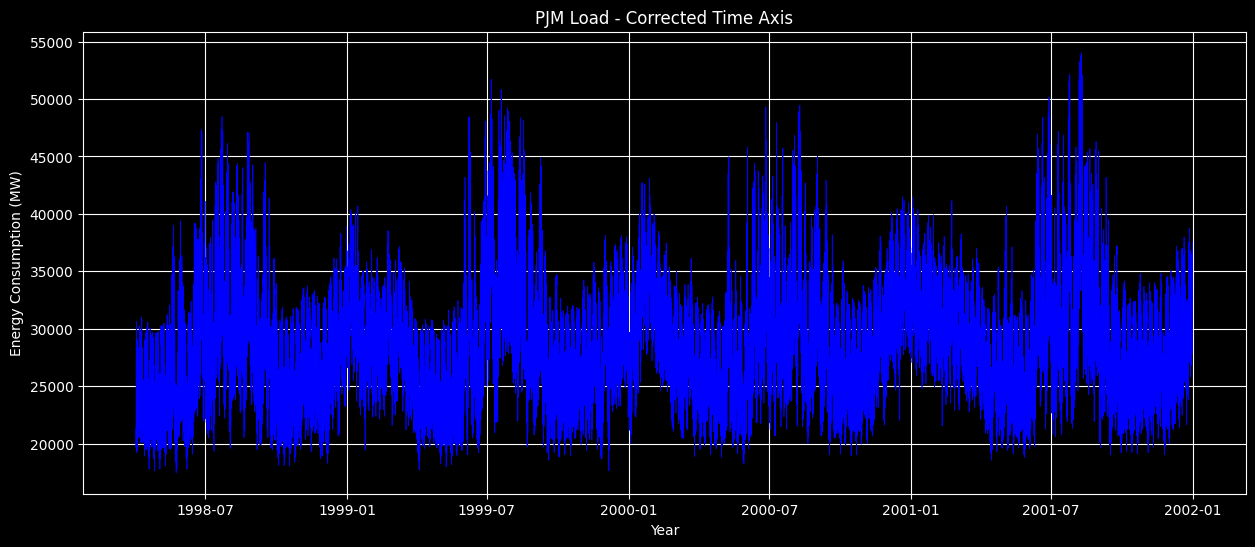

In [66]:
#Genel Grafik
import matplotlib.pyplot as plt

# Grafiklerin bozulmaması için orijinal index'e sahip dataframe'i kullanıyoruz
plt.figure(figsize=(15, 6))
plt.plot(df_prep.index, df_prep['PJM_Load'], color='blue', linewidth=0.5)

plt.title('PJM Load - Corrected Time Axis')
plt.xlabel('Year')
plt.ylabel('Energy Consumption (MW)')
plt.grid(True)
plt.show()

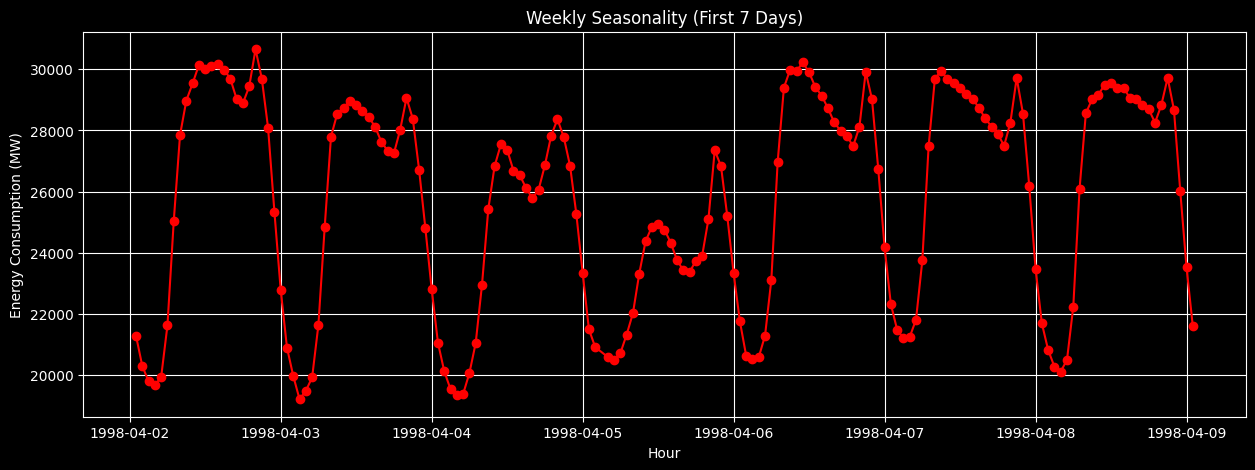

In [60]:
#mevsimlik grafik
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 5))
plt.plot(df_prep['PJM_Load'][:24*7], color='red', marker='o')
plt.title('Weekly Seasonality (First 7 Days)')
plt.xlabel('Hour')
plt.ylabel('Energy Consumption (MW)')
plt.grid(True)
plt.show()

In [59]:
# Time control blog
import pandas as pd

df_prep.index = pd.to_datetime(df_prep.index)

df_prep = df_prep.sort_index()

print("First date after cleaning:", df_prep.index.min())
print("Last date after cleaning:", df_prep.index.max())

print("Total column:", len(df_prep))

First date after cleaning: 1998-04-02 01:00:00
Last date after cleaning: 2001-12-31 23:00:00
Total column: 32871


In [58]:
# --- FEATURE ENGINEERING BLOG ---

# 1. Gecikmeli Özellikler (Lags)
# shift(1) veriyi bir satır aşağı kaydırır, böylece t anına t-1 değerini getirir.
df_prep['lag_1'] = df_prep['PJM_Load'].shift(1)
df_prep['lag_24'] = df_prep['PJM_Load'].shift(24)

# 2. Hareketli Ortalama (Rolling Average)
# Son 24 saatin ortalamasını hesaplar
df_prep['rolling_mean_24'] = df_prep['PJM_Load'].rolling(window=24).mean()

# 3. Boşlukları Temizleme
# Kaydırma (shift) ve Rolling işlemlerinden dolayı ilk 24 satırda NaN (boşluk) oluşur.
# Bunları silmeliyiz çünkü model boş hücre sevmez.
df_prep.dropna(inplace=True)

# Bakalım sütunlar gelmiş mi?
print("The table with new features:")
print(df_prep.head(30))

The table with new features:
                     PJM_Load    lag_1   lag_24  rolling_mean_24
Datetime                                                        
1998-04-02 01:00:00   21291.0  23238.0  22259.0     27582.750000
1998-04-02 02:00:00   20302.0  21291.0  21244.0     27543.500000
1998-04-02 03:00:00   19802.0  20302.0  20651.0     27508.125000
1998-04-02 04:00:00   19675.0  19802.0  20421.0     27477.041667
1998-04-02 05:00:00   19941.0  19675.0  20713.0     27444.875000
1998-04-02 06:00:00   21628.0  19941.0  22526.0     27407.458333
1998-04-02 07:00:00   25032.0  21628.0  25772.0     27376.625000
1998-04-02 08:00:00   27850.0  25032.0  28724.0     27340.208333
1998-04-02 09:00:00   28978.0  27850.0  30075.0     27294.500000
1998-04-02 10:00:00   29536.0  28978.0  30689.0     27246.458333
1998-04-02 11:00:00   30140.0  29536.0  31295.0     27198.333333
1998-04-02 12:00:00   30017.0  30140.0  31539.0     27134.916667
1998-04-02 13:00:00   30118.0  30017.0  31227.0     27088.708

In [65]:
# --- Test / Train / Validation splitting BLOG ---
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- 1. HEDEF VE ÖZELLİK TANIMLAMA ---
y = df_prep['PJM_Load'].shift(-1)
X = df_prep[['lag_1', 'lag_24', 'rolling_mean_24']]

# shift(-1) son satırı NaN yapar, ikisini de aynı anda temizle
mask = y.notna()
X = X[mask]
y = y[mask]

# --- 2. VERİYİ BÖLME (Time-based Split) ---
train_end = int(len(X) * 0.70)
val_end   = int(len(X) * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

# --- 3. ÖLÇEKLENDİRME ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

# --- 4. KONTROL ---
print(f"Train:      X={X_train_scaled.shape} | y={y_train_scaled.shape}")
print(f"Validation: X={X_val_scaled.shape}   | y={y_val_scaled.shape}")
print(f"Test:       X={X_test_scaled.shape}  | y={y_test_scaled.shape}")
print(f"Train Dates: {X_train.index.min()} → {X_train.index.max()}")
print(f"Val Dates:   {X_val.index.min()}   → {X_val.index.max()}")
print(f"Test Dates:  {X_test.index.min()}  → {X_test.index.max()}")

Train:      X=(23009, 3) | y=(23009, 1)
Validation: X=(4930, 3)   | y=(4930, 1)
Test:       X=(4931, 3)  | y=(4931, 1)
Train Dates: 1998-04-02 01:00:00 → 2000-11-15 23:00:00
Val Dates:   2000-11-16 00:00:00   → 2001-06-09 10:00:00
Test Dates:  2001-06-09 11:00:00  → 2001-12-31 22:00:00
